# DeepWiener tutorial: from a polarization map to $C_\ell^{BB}$ and $r$

This notebook walks through the full pipeline of the repository on **one simulated SO-like observation**, using the products that were computed on a cluster.

| # | Stage | Script (`source/`) | Cluster job (`slurm/`) | Cost | In this notebook |
|---|-------|--------------------|------------------------|------|------------------|
| 0 | 2D variance map of the projected noise | `make_variance_map.py` | – | minutes, CPU | **loaded** (`data/aux/`) |
| 1 | Training / validation set | `run_dataset.py` | `data.sh` | hours, ~100 GB RAM | not needed |
| 2 | Network training + Optuna | `training_opt_beam_changed.py` | `train_opt_beam_changed.sh` | days, GPU | **loaded** (`data/models/`, `data/studies/`) |
| 3 | OQE Fisher matrix (2 × 2000 sims) | `compute_fisher.py` → `reduce_fisher.py` | `submit_all.sh` → `reduce_fisher_job.sh` | ~4000 array jobs | **loaded** (`data/spectrum/`) |
| 4 | OQE noise bias (2000 sims) | `compute_bias.py` → `reduce_bias.py` | `submit_all_bias.sh` → `reduce_bias_job.sh` | ~2000 array jobs | **loaded** (`data/spectrum/`) |
| 5 | Simulate "true" maps + NN Wiener filter + $E_\ell$ | `make_true_maps.py` | `true_maps_job.sh` | seconds per sim | **run here** (§2–§4) |
| 6 | NaMaster pseudo-$C_\ell$ (benchmark) | `make_noise_bias.py`, `compute_namaster.py` | `namaster_job.sh` | minutes | optional (§6) |
| 7 | Covariances for the likelihood | `make_covariance.py` | – | seconds | **loaded** (`data/aux/SO_covariances.h5`) |
| 8 | MCMC on $(r, A_\mathrm{lens})$ | `run_cobaya_bb.py` | `job_cobaya_bb.sh` | minutes–hours | short chain (§5) |

Everything runs on a laptop CPU: about 1 min and < 2 GB of RAM (about 3 min with the optional NaMaster section).

**Before running:** the pretrained products are not stored in the repository. Download them (~40 MB) from the release [tutorial-data-v1](https://github.com/Belencostanza/CMBpipeline/releases/tag/tutorial-data-v1) into `tutorial/data/` with
```bash
cd tutorial
bash get_tutorial_data.sh
```
or download `tutorial_data.tar.gz` by hand and extract it inside `tutorial/`.
and use an environment with the packages listed in the README (PyTorch, healpy, CAMB, NaMaster, Optuna, Cobaya, GetDist, h5py, matplotlib).

## 0. Set-up

In [16]:
import os, sys, time
import numpy as np
import torch
import healpy as hp
import matplotlib.pyplot as plt

TUTORIAL_DIR = os.path.abspath("")                     # run the notebook from tutorial/
SOURCE_DIR   = os.path.join(TUTORIAL_DIR, "..", "source")
sys.path.insert(0, SOURCE_DIR)

# the pretrained products are not in the repository: they come from a GitHub release
RELEASE_URL = "https://github.com/Belencostanza/CMBpipeline/releases/tag/tutorial-data-v1"
if not os.path.isdir(os.path.join(TUTORIAL_DIR, "data", "models")):
    raise FileNotFoundError(
        "tutorial/data/ not found. Download the pretrained products first:\n"
        "  cd tutorial && bash get_tutorial_data.sh\n"
        f"or download tutorial_data.tar.gz from {RELEASE_URL} and extract it inside tutorial/.\n"
        "Also make sure the notebook runs from the tutorial/ folder.")

from config_loader import load_config, bin_edges
import utilities
import PowerSpectrum as PP
from geometry import build_geometry
from spectra import fiducial_spectrum, true_spectrum

# optional, slower sections
RUN_MCMC     = True     # §5: short cobaya chain (~1 min)
RUN_NAMASTER = False    # §6: NaMaster benchmark (~1-3 min, a few GB of RAM)

### The configuration file

Every script of the pipeline reads **one** `config.dict` (a Python-literal dictionary with comments). `config_loader.load_config()` validates it, picks the entries that depend on the mask type and turns every folder/file name into an absolute path.

The tutorial uses `config_tutorial.dict`, a copy of `source/config.dict` whose folders point to `tutorial/data/` (inputs) and `tutorial/output/` (anything written here). To run your own analysis you edit the same keys in `source/config.dict` (see the README).

In [17]:
cfg = load_config(os.path.join(TUTORIAL_DIR, "config_tutorial.dict"))

for key in ["mask_type", "nside", "npixels_x", "npixels_y", "fwhm_arcmin", "noise_type",
            "inho_type", "r", "map_rescale_factor", "study_name"]:
    print(f"{key:20s} = {cfg[key]}")
print()
for key in ["model_folder", "study_db", "spectrum_folder", "inho2d_path", "so_hits_path"]:
    print(f"{key:20s} -> {os.path.relpath(cfg[key].replace('sqlite:///', ''), TUTORIAL_DIR)}")

mask_type            = rect
nside                = 512
npixels_x            = 704
npixels_y            = 416
fwhm_arcmin          = 23.0
noise_type           = inho
inho_type            = inho2
r                    = 0.034
map_rescale_factor   = 0.8382
study_name           = plnj3_geo_nCMB_r03_beam_proj2d_eq_maskSOnofreq_rad40_margin8_inhosim2_sinnorm_res_arcmin

model_folder         -> data/models
study_db             -> data/studies/plnj3_geo_nCMB_r03_beam_proj2d_eq_maskSOnofreq_rad40_margin8_inhosim2_sinnorm_res_arcmin.db
spectrum_folder      -> data/spectrum
inho2d_path          -> data/aux/var_map_sims100_SO_inho2_res_arcmin.npy
so_hits_path         -> data/masks/norm_nHits_SA_35FOV_ns512.fits


## 1. Sky patch and projection to the plane

`geometry.build_geometry(cfg)` builds everything that depends only on the sky region:
* the HEALPix mask of the SO-like patch (from the hits map) and the noise variance map on the sphere,
* the equidistant azimuthal projection to a $704\times416$ Cartesian grid (`proj`, `z_eq`, pixel sizes `dx`, `dy`),
* the 2D binary mask and the rotation angle $\psi$ that takes $(Q,U)$ from the sphere to the plane basis,
* the 2D pixel variance of the projected noise (`inho2d`, output of `make_variance_map.py`), which is the 4th input channel of the network.

In [18]:
t0 = time.time()
geo = build_geometry(cfg, load_inho2d=True, variance=True)
print(f"built in {time.time()-t0:.1f} s")
print("plane grid (ny, nx):", geo.mask2d.shape, "  pixel size: %.2f' x %.2f'" % (np.degrees(geo.dx)*60, np.degrees(geo.dy)*60))
print("f_sky = %.3f" % geo.mask.mean())

built in 0.5 s
plane grid (ny, nx): (416, 704)   pixel size: 9.55' x 9.32'
f_sky = 0.111


/home/belen/miniconda3/envs/torch_cmb/lib/python3.10/site-packages/healpy/visufunc.py:1504: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)
/tmp/ipykernel_35742/87590115.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


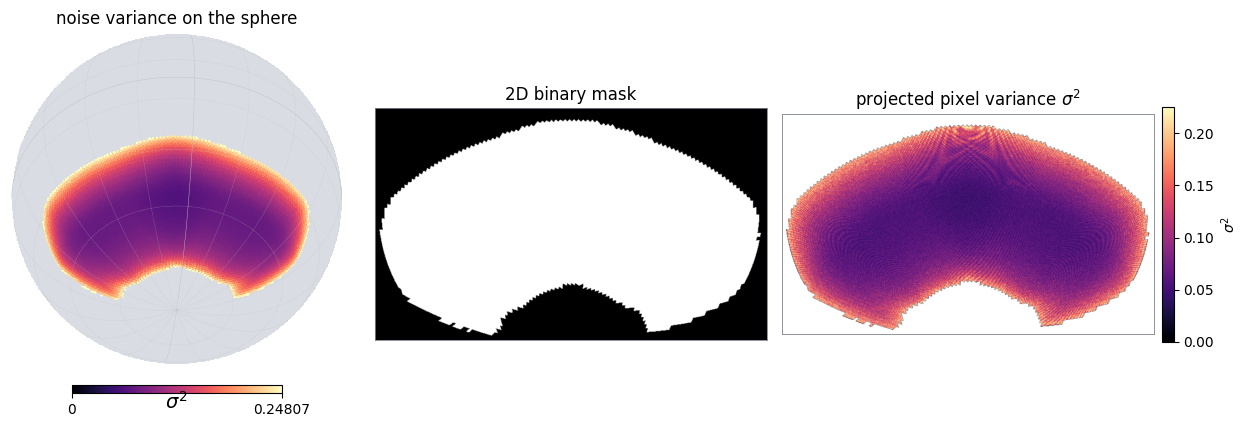

In [19]:
# ---- plotting helpers (same style as the pipeline figure) -------------------
lon0, lat0 = hp.vec2ang(geo.vec_center, lonlat=True)          # centre of the patch

def show_sph(m, title, sub, cmap="RdBu_r", vmin=None, vmax=None, unit=r"$\mu$K"):
    # orthographic view centred on the patch; pixels outside the mask in grey
    mm = np.where(geo.mask > 0, m, hp.UNSEEN)
    hp.orthview(mm, rot=(float(lon0[0]), float(lat0[0])), half_sky=True, sub=sub, fig=fig.number,
                title=title, cmap=cmap, min=vmin, max=vmax, unit=unit, badcolor="#d9dde3",
                bgcolor="white", notext=True)
    hp.graticule(dpar=20, dmer=20, color="0.75", lw=0.3, verbose=False)

def show_pln(ax, m, title, cmap="RdBu_r", vmin=None, vmax=None, unit=r"$\mu$K", mask=None, cbar=True):
    # plane map; pixels outside the 2D mask hidden, no pixel ticks
    mask = geo.mask2d if mask is None else mask
    im = ax.imshow(np.ma.masked_where(mask == 0, m), origin="lower", cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor("#7c828c"); sp.set_linewidth(0.6)
    ax.set_title(title)
    if cbar:
        cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        if unit: cb.set_label(unit)
    return im

def smooth_beam(m):
    # convolve a plane map with the Gaussian beam (FFT on the plane grid)
    ny, nx = m.shape
    lx = np.fft.rfftfreq(nx, d=geo.dx) * 2 * np.pi
    ly = np.fft.fftfreq(ny, d=geo.dy) * 2 * np.pi
    ell2 = lx[None, :]**2 + ly[:, None]**2
    sigma_b = cfg["fwhm_rad"] / np.sqrt(8 * np.log(2))
    return np.fft.irfft2(np.fft.rfft2(m) * np.exp(-0.5 * ell2 * sigma_b**2), s=m.shape)

def sym(*maps, mask=None, q=99):
    # symmetric colour limit shared by several maps (percentile inside the mask)
    mask = geo.mask2d if mask is None else mask
    return max(np.percentile(np.abs(m[mask > 0]), q) for m in maps)

# ---- noise model: sphere and plane ------------------------------------------
vmax_var = np.percentile(geo.variance_map[geo.mask > 0], 99)

fig = plt.figure(figsize=(13, 4))
show_sph(geo.variance_map, r"noise variance on the sphere", sub=(1, 3, 1),
         cmap="magma", vmin=0, vmax=vmax_var, unit=r"$\sigma^2$")
ax = fig.add_subplot(1, 3, 2); show_pln(ax, geo.mask2d, "2D binary mask", cmap="Greys_r", cbar=False,
                                        mask=np.ones_like(geo.mask2d))
ax = fig.add_subplot(1, 3, 3); show_pln(ax, geo.inho2d, r"projected pixel variance $\sigma^2$",
                                        cmap="magma", vmin=0, vmax=np.percentile(geo.inho2d[geo.mask2d > 0], 99),
                                        unit=r"$\sigma^2$")
plt.tight_layout(); plt.show()

## 2. Simulate one observation

The network and the OQE products were built around the fiducial model ($r = 0.034$, $A_\mathrm{lens}=1$). As in `make_true_maps.py`, we simulate the observation from a **different "true" spectrum**, set in the `true_maps` section of the config:
$C_\ell^{BB,\mathrm{true}} = r_\mathrm{new}\, C_\ell^{BB,\mathrm{prim}} + A_\mathrm{lens,new}\, C_\ell^{BB,\mathrm{lens}}$.

`make_maps_inho_pln_cls` draws the CMB on the sphere, applies the beam, adds inhomogeneous noise, masks, rotates $(Q,U)$ and interpolates onto the plane. The seeds make the realization reproducible.

In [20]:
tm = cfg["true_maps"]
print("true spectrum: r = %.3f, Alens = %.3f" % (tm["r_new"], tm["Alens_new"]))

clfid_tt, clfid_ee, clfid_bb = fiducial_spectrum(cfg)          # fiducial (CAMB), r = cfg["r"]
cltrue_tt, cltrue_ee, cltrue_bb = true_spectrum(cfg, tm)       # "true" sky of the simulation
ele = np.arange(len(clfid_bb))

cls = geo.make_data._create_spectrum_array(cltrue_tt, cltrue_ee, cltrue_bb)
Q_pln, U_pln, mask2d, Q_sph, U_sph = geo.make_data.make_maps_inho_pln_cls(
    cls, geo.variance_map, geo.proj, geo.valid_index, geo.mask, geo.z_eq, geo.psi,
    cfg["mask_type"], geo.mask2d, tm["cmb_seed"], tm["noise_seed"])

# network input: (N, 4, ny, nx) = Q, U, mask, sigma^2   (same layout as the training set)
data = torch.from_numpy(np.stack([Q_pln, U_pln, mask2d, geo.inho2d])[None].astype(np.float32))
print("data cube:", tuple(data.shape))

true spectrum: r = 0.028, Alens = 1.000
data cube: (1, 4, 416, 704)


/tmp/ipykernel_35742/270378773.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


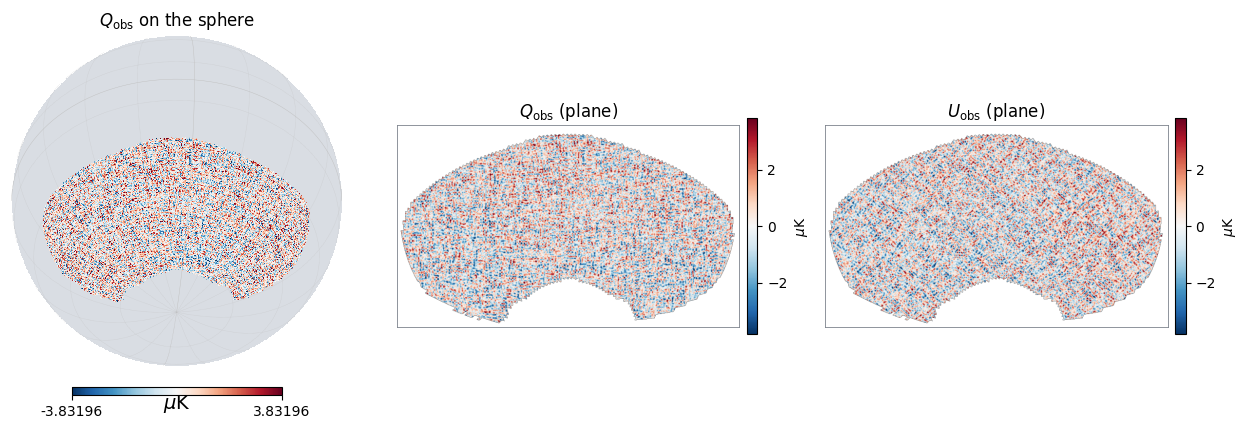

In [21]:
v = sym(Q_pln, U_pln)

fig = plt.figure(figsize=(13, 4))
show_sph(Q_sph, r"$Q_\mathrm{obs}$ on the sphere", sub=(1, 3, 1), vmin=-v, vmax=v)
ax = fig.add_subplot(1, 3, 2); show_pln(ax, Q_pln, r"$Q_\mathrm{obs}$ (plane)", vmin=-v, vmax=v)
ax = fig.add_subplot(1, 3, 3); show_pln(ax, U_pln, r"$U_\mathrm{obs}$ (plane)", vmin=-v, vmax=v)
plt.tight_layout(); plt.show()

## 3. Wiener filter with the trained network

`PowerSpectrum.get_models` opens the Optuna study, takes the **best trial**, rebuilds `DeepWiener_threechannels` with its hyper-parameters and loads the weights from `model_folder`. Nothing is trained here.

`prediction` normalises the input exactly as during training (mean subtraction and `map_rescale_factor`), runs the network and undoes the rescaling.

The network estimates the signal **before** the beam: during training the loss (`losses.py`) convolves the network output with the beam before comparing it with the data. The Wiener-filtered maps are therefore sharper and can have a larger amplitude than the beam-smoothed data. The last column convolves them with the beam again: on the same colour scale as the data, they show the large-scale signal with the noise removed.

6.3 M parameters
Wiener filter in 0.98 s


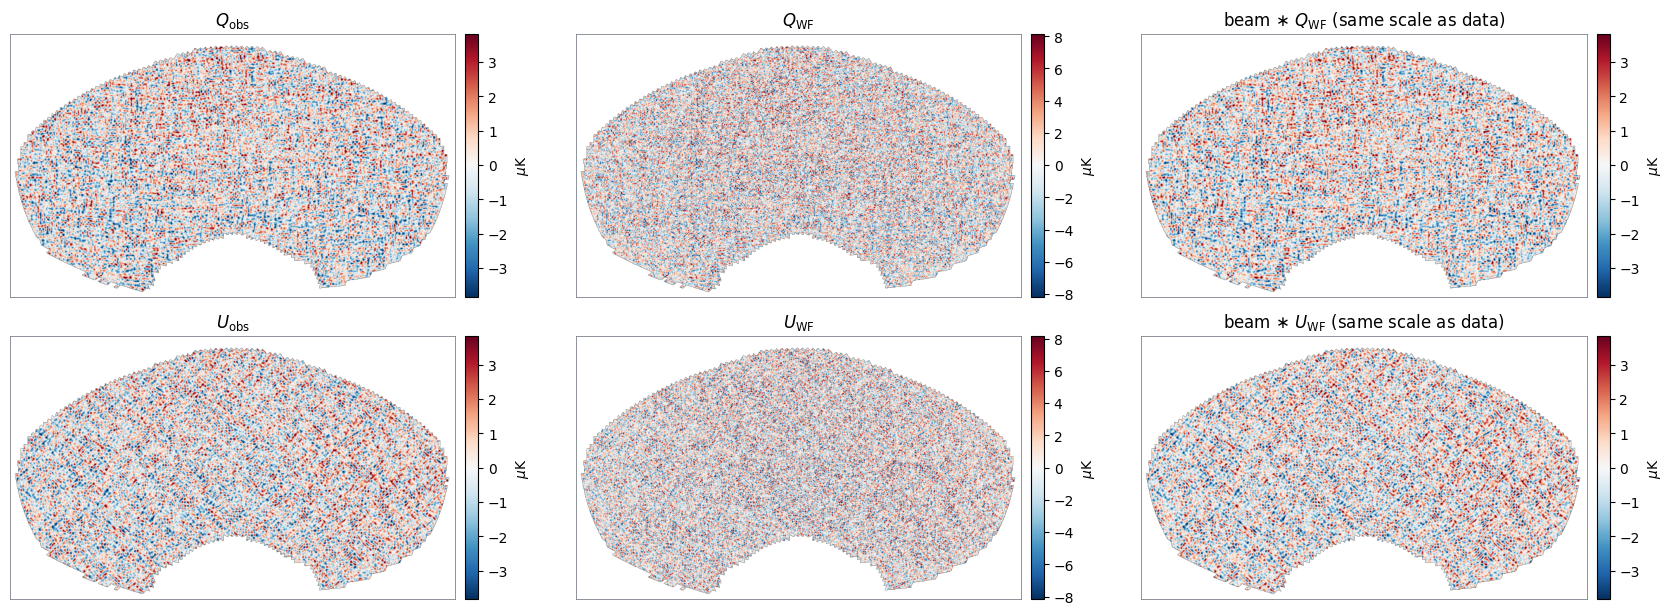

In [22]:
bins  = bin_edges(cfg)
nbins = len(bins) - 1

ps = PP.PowerSpectrum(cfg["nside"], cfg["npixels_x"], cfg["npixels_y"], geo.dx, geo.dy, cfg["fwhm_arcmin"],
                      nbins, bins, cfg["map_rescale_factor"], DEFAULT_NOISE_LEVEL=cfg["DEFAULT_NOISE_LEVEL"],
                      mask_type=cfg["mask_type"], noise_type=cfg["noise_type"], nsamples_fisher=data.shape[0])

model = ps.get_models(cfg["model_path"], cfg["study_name"], storage=cfg["study_db"])
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f} M parameters")

t0 = time.time()
Q_wf, U_wf = ps.prediction(data, model)
print(f"Wiener filter in {time.time()-t0:.2f} s")

v_wf = sym(Q_wf[0], U_wf[0])
fig, ax = plt.subplots(2, 3, figsize=(17, 6.2))
for row, (obs, wf, name) in enumerate([(Q_pln, Q_wf[0], "Q"), (U_pln, U_wf[0], "U")]):
    show_pln(ax[row, 0], obs,              rf"${name}_\mathrm{{obs}}$",                    vmin=-v, vmax=v)
    show_pln(ax[row, 1], wf,               rf"${name}_\mathrm{{WF}}$",                     vmin=-v_wf, vmax=v_wf)
    show_pln(ax[row, 2], smooth_beam(wf),  rf"beam $\ast$ ${name}_\mathrm{{WF}}$ (same scale as data)", vmin=-v, vmax=v)
plt.tight_layout(); plt.show()

The E/B decomposition of the filtered maps is done in the plane with FFTs (`get_nn_outputs`). The B-mode map is much fainter than E, as expected (note the different colour scales).

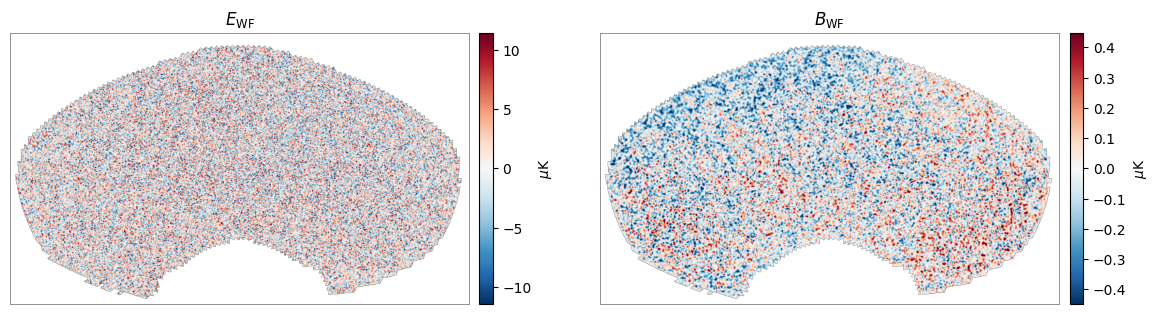

In [23]:
E_wf, B_wf = ps.get_nn_outputs(data, model)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
vE, vB = sym(E_wf[0]), sym(B_wf[0])
show_pln(ax[0], E_wf[0], r"$E_\mathrm{WF}$", vmin=-vE, vmax=vE)
show_pln(ax[1], B_wf[0], r"$B_\mathrm{WF}$", vmin=-vB, vmax=vB)
plt.tight_layout(); plt.show()

## 4. Optimal quadratic estimator

For every band $\ell$ the quadratic statistic of the Wiener-filtered map is
$$E_\ell = \frac{1}{2}\sum_k \frac{|\hat s_k|^2}{\Theta_{\ell}\,S_k}\,,$$
and the band powers are obtained by expanding around the fiducial model:
$$\hat\Theta = \Theta_\mathrm{fid} + F^{-1}\,(E_\ell - b_\ell), \qquad \mathrm{Cov}(\hat\Theta) \simeq F^{-1}.$$

The Fisher matrix $F$ (average of the $\pm0.5$ perturbations, `k0`/`k1`) and the noise bias $b_\ell$ were computed on the cluster with 2000 simulations each (`compute_fisher.py`, `compute_bias.py` + reductions). Here they are only loaded.

In [24]:
# fiducial spectra in the plane and binned (same as make_true_maps.py)
ell_flat, clee_flat = ps.flat_spectrum_xy(clfid_ee)
_,        clbb_flat = ps.flat_spectrum_xy(clfid_bb)
_, clee_bin, _ = utilities.bineado(ele[1:], clfid_ee[1:], bins)
_, clbb_bin, _ = utilities.bineado(ele[1:], clfid_bb[1:], bins)

El_ee, El_bb = ps.fiducial(data, model, ell_flat, clee_flat, clbb_flat, clee_bin, clbb_bin, all=True)

# precomputed OQE products
sp, tag, lab = cfg["spectrum_folder"], cfg["spectrum_tag"], cfg["binning"]["label"]
nF, nB = cfg["oqe"]["nsamples_fisher"], cfg["oqe"]["nsamples_bias"]
fisher_bb = np.mean([np.load(f"{sp}fisher_mean{nF}_bb_{lab}_k{k}_{tag}.npy") for k in (0, 1)], axis=0)
bias_bb   = np.load(f"{sp}bias_mean{nB}_bb_{lab}_{tag}.npy")

# band powers (as in run_cobaya_bb.py / make_covariance.py)
_, clbb_bin_fid, _  = utilities.bineado(ele, clfid_bb, bins)
_, clbb_bin_true, _ = utilities.bineado(ele, cltrue_bb, bins)
clbb_oqe, _, _ = utilities.correction_modified(El_bb, bias_bb, fisher_bb, clbb_bin_fid,
                                               nsamples=El_bb.shape[0], nbins=nbins)
sigma_oqe = np.sqrt(np.diag(np.linalg.inv(fisher_bb)))

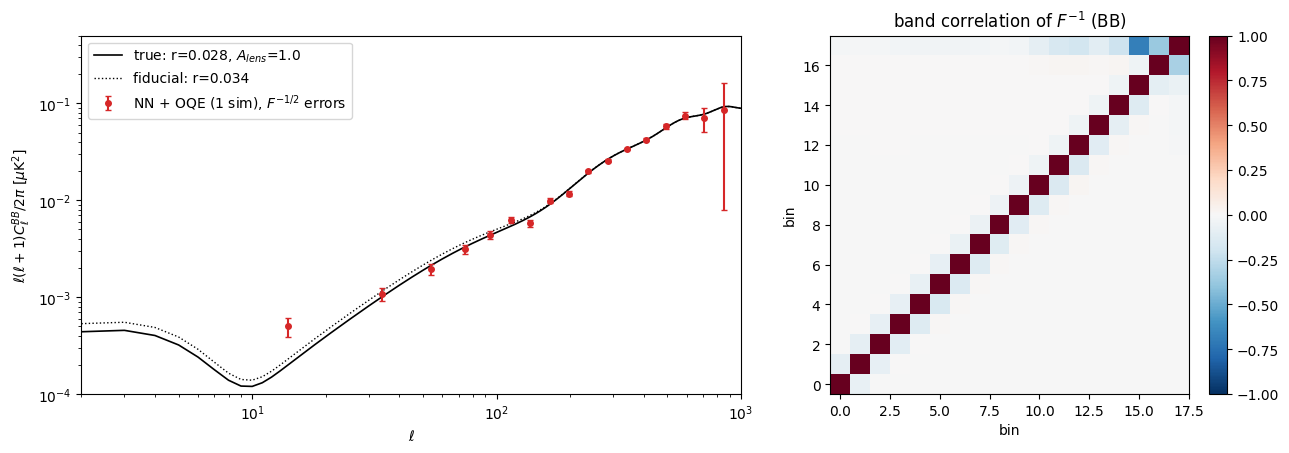

(estimate - true)/sigma per bin: [-0.81  0.32 -0.69 -0.52  0.04  1.73 -2.12  1.42 -1.94  0.92 -0.91 -0.14
 -0.08  0.74  0.72 -0.46 -0.07  1.49]


In [25]:
ell_c = 0.5 * (bins[1:] + bins[:-1])
dl = lambda cl, l: l * (l + 1) * cl / (2 * np.pi)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.6, 1]})
l = ele[2:1100]
ax[0].plot(l, dl(cltrue_bb[l], l), "k-", lw=1.2, label=f"true: r={tm['r_new']}, $A_{{lens}}$={tm['Alens_new']}")
ax[0].plot(l, dl(clfid_bb[l], l), "k:", lw=1, label=f"fiducial: r={cfg['r']}")
ax[0].errorbar(ell_c[:-1], dl(clbb_oqe, ell_c)[:-1], yerr=dl(sigma_oqe, ell_c)[:-1], fmt="o", color="C3",
               ms=4, capsize=2, label=r"NN + OQE (1 sim), $F^{-1/2}$ errors")
ax[0].set_xlabel(r"$\ell$"); ax[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlim(2, 1000); ax[0].set_ylim(1e-4, 0.5); ax[0].legend(loc="upper left")

corr = np.linalg.inv(fisher_bb); corr = corr / np.sqrt(np.outer(np.diag(corr), np.diag(corr)))
im = ax[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
ax[1].set_title(r"band correlation of $F^{-1}$ (BB)"); ax[1].set_xlabel("bin"); ax[1].set_ylabel("bin")
plt.colorbar(im, ax=ax[1], fraction=0.045)
plt.tight_layout(); plt.show()

print("(estimate - true)/sigma per bin:", np.round((clbb_oqe - clbb_bin_true) / sigma_oqe, 2))

## 5. Cosmological inference on $(r, A_\mathrm{lens})$

`run_cobaya_bb.py` fits $C_\ell^{BB} = r\,C_\ell^{\mathrm{prim}} + A_\mathrm{lens}C_\ell^{\mathrm{lens}}$ to the band powers with a Gaussian likelihood. The covariance comes from the scatter of 200 simulations (`make_covariance.py`, stored in `data/aux/SO_covariances.h5`). The last band is dropped, as in the script.

Below is the same likelihood run on the single-simulation estimate of §4 with a short chain (`max_samples` in the `cobaya` section). On the cluster the chain runs until $R-1 <$ `rminus1`.

In [ ]:
if RUN_MCMC:
    import h5py
    from cobaya.run import run
    from getdist import MCSamples, plots

    cob  = cfg["cobaya"]
    fid  = cfg["cosmo_fid"]
    lmax_th   = cob["lmax_theory"]
    nbins_use = nbins - 1

    with h5py.File(cfg["cobaya_paths"]["datafile"], "r") as f:
        inv_cov = np.linalg.inv(f["covariance/oqe"][:][:nbins_use, :nbins_use])

    _, _, clBB_prim, clBB_lens = utilities.get_templates_fiducial(
        H0=fid["H0"], ombh2=fid["ombh2"], omch2=fid["omch2"], tau=fid["tau"],
        ns=fid["ns"], As=fid["As"], mnu=fid["mnu"], r_ref=cfg["r"], lmax=lmax_th)
    ell_th = np.arange(lmax_th + 1)

    def clbb_binned(r, Alens):
        return utilities.bineado(ell_th, utilities.clbb_theory(r, Alens, clBB_prim, clBB_lens), bins)[1]

    cl_data = clbb_oqe[:nbins_use]

    def loglike(r, Alens):
        d = cl_data - clbb_binned(r, Alens)[:nbins_use]
        return -0.5 * d @ inv_cov @ d

    info = {
        "params": {
            "r":     {"prior": {"min": 0.0, "max": 0.1}, "ref": 0.03, "proposal": 0.005, "latex": "r"},
            "Alens": {"prior": {"min": 0.5, "max": 1.5}, "ref": 1.0,  "proposal": 0.01,  "latex": r"A_\mathrm{lens}"},
        },
        "likelihood": {"bb": {"external": loglike}},
        "sampler": {"mcmc": {"Rminus1_stop": cob["rminus1"], "max_samples": cob["max_samples"],
                             "learn_proposal": True}},
        "output": None,            # in memory; run_cobaya_bb.py writes chains to chains_folder
    }
    t0 = time.time()
    _, sampler = run(info, stop_at_error=True)
    print(f"MCMC: {len(sampler.products()['sample'])} samples in {time.time()-t0:.0f} s")

    samples = MCSamples(samples=sampler.products()["sample"].data[["r", "Alens"]].to_numpy()[
                            len(sampler.products()["sample"]) // 3:],      # drop first third as burn-in
                        names=["r", "Alens"], labels=["r", r"A_\mathrm{lens}"])
    print(samples.getInlineLatex("r", limit=1), "   ", samples.getInlineLatex("Alens", limit=1))

    g = plots.get_subplot_plotter(width_inch=5)
    g.triangle_plot(samples, filled=True, markers={"r": tm["r_new"], "Alens": tm["Alens_new"]})
    plt.show()

## 6. (Optional) Benchmark with the pseudo-$C_\ell$ estimator

`compute_namaster.py` estimates $C_\ell^{BB}$ directly on the sphere with NaMaster ($B$-mode purification, apodised mask, same bins plus one extended bin). The noise bias comes from `make_noise_bias.py`. Here it runs on the **same** realization. Computing the coupling matrix at `nside = 512` takes about a minute on a multi-core laptop, so it is off by default: set `RUN_NAMASTER = True` at the top to run it.

In [ ]:
if RUN_NAMASTER:
    import pymaster as nmt

    lmax_sph = 3 * cfg["nside"] - 1
    beam = utilities.bl(np.radians(cfg["fwhm_arcmin"] / 60), len(ele) - 1)[:lmax_sph + 1]
    mask_apod = nmt.mask_apodization(geo.mask, aposize=cfg["apo_scale"], apotype="Smooth")

    edges = np.append(np.asarray(bins, dtype=int), lmax_sph + 1)
    nmt_bins = nmt.NmtBin.from_edges(edges[:-1], edges[1:])

    f2 = nmt.NmtField(mask_apod, [mask_apod * Q_sph, mask_apod * U_sph], beam=beam,
                      purify_b=cfg["namaster"]["purify_b"], masked_on_input=True)
    t0 = time.time()
    wsp = nmt.NmtWorkspace()
    wsp.compute_coupling_matrix(f2, f2, nmt_bins)
    print(f"coupling matrix in {time.time()-t0:.0f} s")

    cl_noise = np.load(cfg["namaster_paths"]["noise_bias"])
    clbb_nmt = wsp.decouple_cell(nmt.compute_coupled_cell(f2, f2), cl_noise=cl_noise)[3][:nbins]

    plt.figure(figsize=(8, 4.5))
    plt.plot(l, dl(cltrue_bb[l], l), "k-", lw=1.2, label="true")
    plt.errorbar(ell_c[:-1] * 0.97, dl(clbb_oqe, ell_c)[:-1], yerr=dl(sigma_oqe, ell_c)[:-1], fmt="o", color="C3", ms=4, capsize=2, label="NN + OQE")
    plt.plot(ell_c[:-1] * 1.03, dl(clbb_nmt, ell_c)[:-1], "s", color="C7", ms=4, label="NaMaster (same sim)")
    plt.xscale("log"); plt.yscale("log"); plt.xlim(2, 1000); plt.ylim(1e-4, 0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$D_\ell^{BB}$ [$\mu$K$^2$]"); plt.legend(); plt.show()

## 7. Going further: running your own analysis

To reproduce or change any stage, edit `source/config.dict` (the README lists the keys) and run the scripts from `source/`, in the order of the table at the top. The heavy stages have Slurm templates in `slurm/`:

```bash
cd source
python make_variance_map.py                  # 2D noise variance map            -> aux_folder
sbatch ../slurm/data.sh                      # train / valid sets               -> data_folder
sbatch ../slurm/train_opt_beam_changed.sh    # training + Optuna (GPU)          -> model_folder, study_folder
bash   ../slurm/submit_all.sh                # Fisher, 2 x 2000 array jobs      -> spectrum_folder
bash   ../slurm/submit_all_bias.sh           # noise bias, 2000 array jobs      -> spectrum_folder
sbatch ../slurm/reduce_fisher_job.sh; sbatch ../slurm/reduce_bias_job.sh
sbatch ../slurm/true_maps_job.sh             # simulations with the "true" spectrum + E_l
python make_noise_bias.py; sbatch ../slurm/namaster_job.sh   # NaMaster benchmark
python make_covariance.py                    # covariances for the likelihood   -> aux_folder
sbatch ../slurm/job_cobaya_bb.sh             # MCMC on (r, Alens)               -> chains_folder
```

Key things to keep consistent:
* The **network, the Fisher matrix and the noise bias depend on the sky patch, the beam, the noise model, the projection grid and the fiducial spectrum**. If you change `mask_type`, `npixels_*`, `fwhm_arcmin`, `noise_type`/`inho_type`, `DEFAULT_NOISE_LEVEL` or `r`, you must regenerate stages 0–4.
* To evaluate **new "true" skies** with the existing products (as in this notebook), only edit the `true_maps` / `namaster` / `cobaya` sections and rerun stages 5–8.
* To reuse the pretrained products of this tutorial in the scripts, point `WF_CONFIG` to `tutorial/config_tutorial.dict` (e.g. `WF_CONFIG=../tutorial/config_tutorial.dict python make_true_maps.py`).